# Epilepsy
Eleonora Vernassa

## 1-Studio del DataSet

In [3]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carichiamo il dataset e lo stampiamo
df_temp = pd.read_excel('EEG-data.xlsx')
if 'Unnamed: 0' in df_temp.columns:
    df_temp = df_temp.drop(columns=['Unnamed: 0'])

## 2-Divisione del dataset per livello di intensità e confronto

In [4]:
# Estraiamo i segnali di livello 1
df1 = df_temp.loc[df_temp['y']==1].copy().drop(columns = ['y'])

In [5]:
# Estraiamo i segnali di livello 2
df2 = df_temp.loc[df_temp['y']==2].copy().drop(columns = ['y'])

In [6]:
# Estraiamo i segnali di livello 3
df3 = df_temp.loc[df_temp['y']==3].copy().drop(columns = ['y'])

In [7]:
# Estraiamo i segnali di livello 4
df4 = df_temp.loc[df_temp['y']==4].copy().drop(columns = ['y'])

In [8]:
row1 = df1.iloc[0]
row2 = df2.iloc[0]
row3 = df3.iloc[0]
row4 = df4.iloc[0]

# fig = plt.figure(figsize=(12,12))
# plt.subplot(2,2,1)
# plt.plot(row1)
# plt.xticks([])
# plt.title("Misurazioni livello 1")
# # plt.ylim(-120, 90) # Set y-axis 

# plt.subplot(2,2,2)
# plt.plot(row2)
# plt.xticks([])
# plt.title("Misurazioni livello 2")
# # plt.ylim(-120, 90) # Set y-axis 

# plt.subplot(2,2,3)
# plt.plot(row3)
# plt.xticks([])
# plt.title("Misurazioni livello 3")
# # plt.ylim(-120, 90) # Set y-axis 

# plt.subplot(2,2,4)
# plt.plot(row4)
# plt.xticks([])
# plt.title("Misurazioni livello 4")
# # plt.ylim(-120, 90) # Set y-axis 

# plt.show()

## 3-Addestramento rete per i segnali di livello 2 e 3

In [9]:
# Importiamo le librerie necessarie
from sklearn.preprocessing import StandardScaler
from sklearn import svm, datasets

In [10]:
# Normalizzazione dei dataset
scaler = StandardScaler()

scale2 = pd.DataFrame(scaler.fit_transform(df2), columns=df2.columns, index=df2.index)
scale3 = pd.DataFrame(scaler.fit_transform(df3), columns=df3.columns, index=df3.index)

### 3.1-Ricerca degli outliers

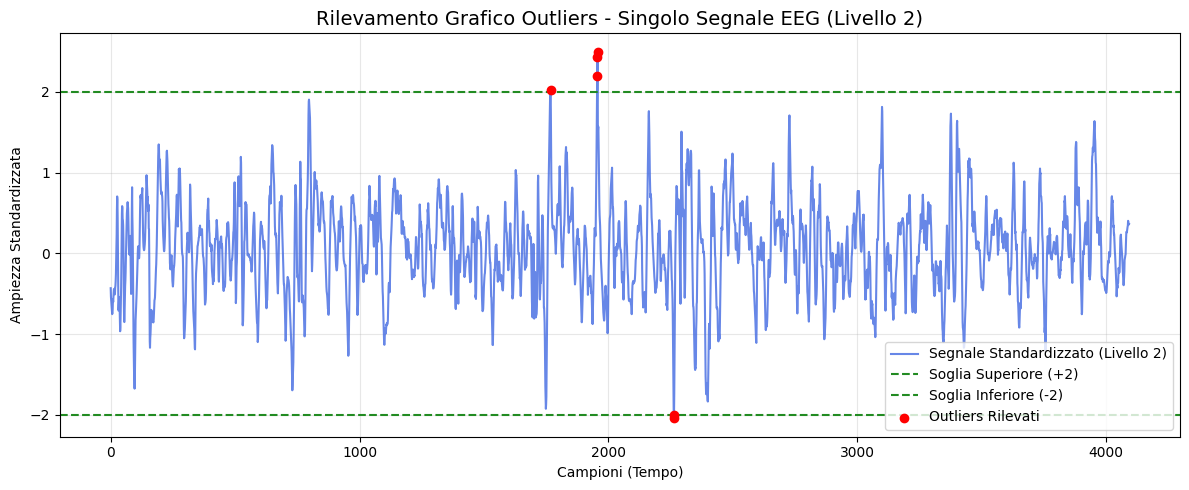

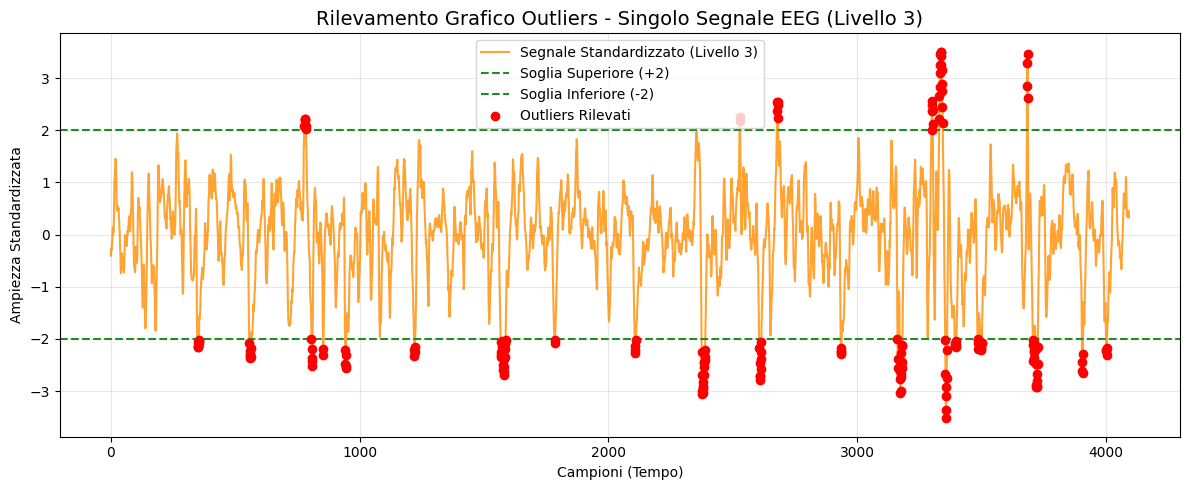

In [11]:
# --- PLOT GRAFICO OUTLIERS  ---
soglia = 2 # 2 volte la std

# Plot per un segnale test di Livello 2
segnale_test_2 = scale2.iloc[2].values # Usiamo .values per avere un asse X numerico pulito

plt.figure(figsize=(12, 5))
plt.plot(segnale_test_2, label="Segnale Standardizzato (Livello 2)", color='royalblue', alpha=0.8)

# Linee di soglia
plt.axhline(y=soglia, color='forestgreen', linestyle='--', label=f'Soglia Superiore (+{soglia})')
plt.axhline(y=-soglia, color='forestgreen', linestyle='--', label=f'Soglia Inferiore (-{soglia})')

# Troviamo e plottiamo i pallini rossi
x_out_2 = np.where(np.abs(segnale_test_2) > soglia)[0]
y_out_2 = segnale_test_2[x_out_2]
plt.scatter(x_out_2, y_out_2, color='red', zorder=5, label='Outliers Rilevati')

plt.title("Rilevamento Grafico Outliers - Singolo Segnale EEG (Livello 2)", fontsize=14)
plt.xlabel("Campioni (Tempo)"); plt.ylabel("Ampiezza Standardizzata")
plt.legend(loc='best'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot per un segnale di Livello 3
segnale_test_3 = scale3.iloc[2].values

plt.figure(figsize=(12, 5))
plt.plot(segnale_test_3, label="Segnale Standardizzato (Livello 3)", color='darkorange', alpha=0.8)

# Linee di soglia
plt.axhline(y=soglia, color='forestgreen', linestyle='--', label=f'Soglia Superiore (+{soglia})')
plt.axhline(y=-soglia, color='forestgreen', linestyle='--', label=f'Soglia Inferiore (-{soglia})')

# Troviamo e plottiamo i pallini rossi
x_out_3 = np.where(np.abs(segnale_test_3) > soglia)[0]
y_out_3 = segnale_test_3[x_out_3]
plt.scatter(x_out_3, y_out_3, color='red', zorder=5, label='Outliers Rilevati')

plt.title("Rilevamento Grafico Outliers - Singolo Segnale EEG (Livello 3)", fontsize=14)
plt.xlabel("Campioni (Tempo)"); plt.ylabel("Ampiezza Standardizzata")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# RICERCA OUTLIERS
def ricerca_outlier(df, valore_soglia):
    matrice_is_outlier = abs(df) > valore_soglia
    conta_outlier = matrice_is_outlier.sum(axis=1)
    return conta_outlier / df.shape[1] * 100

# --- TABELLE ANALISI OUTLIERS ---
valori_soglia = [1, 1.5, 2, 2.5, 3]
perc_max_anomalie = [10, 20, 30, 40, 50, 60, 70, 80, 90]

print("\t\tTabella numero outlier per Livello 2: ")
print("Val.soglia", end='\t')
for p in perc_max_anomalie:
    print(f"{p}%", end='\t')
print()
for v in valori_soglia:
    print(v, end='\t\t')
    conta_outlier_perc = ricerca_outlier(scale2, v)
    for p in perc_max_anomalie:
        # Conto il numero di righe che superano la % massima di anomalie
        count = (conta_outlier_perc >= p).sum()
        print(count, end='\t')
    print()

print("\n\t\tTabella numero outlier per Livello 3: ")
print("Val.soglia", end='\t')
for p in perc_max_anomalie:
    print(f"{p}%", end='\t')
print()
for v in valori_soglia:
    print(v, end='\t\t')
    conta_outlier_perc = ricerca_outlier(scale3, v)
    for p in perc_max_anomalie:
        # Conto il numero di righe che superano la % massima di anomalie
        count = (conta_outlier_perc >= p).sum()
        print(count, end='\t')
    print()
print("\n" + "="*50 + "\n")

		Tabella numero outlier per Livello 2: 
Val.soglia	10%	20%	30%	40%	50%	60%	70%	80%	90%	
1		63	40	21	8	6	4	3	1	0	
1.5		26	11	7	4	3	2	1	0	0	
2		13	5	4	2	2	2	0	0	0	
2.5		6	4	2	2	1	0	0	0	0	
3		5	2	2	1	0	0	0	0	0	

		Tabella numero outlier per Livello 3: 
Val.soglia	10%	20%	30%	40%	50%	60%	70%	80%	90%	
1		83	65	44	17	7	2	0	0	0	
1.5		52	16	5	1	0	0	0	0	0	
2		12	4	1	0	0	0	0	0	0	
2.5		4	1	0	0	0	0	0	0	0	
3		2	0	0	0	0	0	0	0	0	




### 3.2 - Studio dei dataset con e senza outliers
Fissiamo una soglia di $2*\sigma$ e consideriamo i segnali che hanno una percentuale di outliers maggiore o uguale al 30%

Dopo aver fatto uno studio preliminare mettendo a confronto i kernel, analizziamo i dataset con GridSearchCV valutando i kernel: $\{$'linear', 'poly' (degree = 2), 'rbf'$\}$ e variando i valori di $C \in \{0.001, 0.01, 0.1, 1, 10\}$.

In [13]:
# Importiamo le librerie necessarie
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

In [14]:
# Cerchiamo gli indici degli outliers e li rimuoviamo dal dataset
perc_toll = 30

idx2_no_out = ricerca_outlier(scale2, soglia) > perc_toll
idx3_no_out = ricerca_outlier(scale3, soglia) > perc_toll

# Dati originali puliti dagli outliers
df2_no_out_raw = df2[~idx2_no_out].copy()
df3_no_out_raw = df3[~idx3_no_out].copy()

# Aggiungiamo le etichette y ai dati originali
df2_labeled = df2.copy(); df2_labeled['y'] = 2
df3_labeled = df3.copy(); df3_labeled['y'] = 3

df2_no_out_raw['y'] = 2
df3_no_out_raw['y'] = 3

# DATASET 1: CON OUTLIERS
train_out_raw = pd.concat([df2_labeled.iloc[:80], df3_labeled.iloc[:80]])
test_out_raw = pd.concat([df2_labeled.iloc[80:], df3_labeled.iloc[80:]])

X_train_out_raw = train_out_raw.drop(columns=['y'])
y_train_out = train_out_raw['y']
X_test_out_raw = test_out_raw.drop(columns=['y'])
y_test_out = test_out_raw['y']

# Normalizzazione
X_train_out = pd.DataFrame(scaler.fit_transform(X_train_out_raw), columns=X_train_out_raw.columns, index=X_train_out_raw.index)
X_test_out = pd.DataFrame(scaler.transform(X_test_out_raw), columns=X_test_out_raw.columns, index=X_test_out_raw.index)

# DATASET 2: SENZA OUTLIERS
train_no_out_raw = pd.concat([df2_no_out_raw.iloc[:80], df3_no_out_raw.iloc[:80]])
test_no_out_raw = pd.concat([df2_no_out_raw.iloc[80:], df3_no_out_raw.iloc[80:]])

X_train_no_raw = train_no_out_raw.drop(columns=['y'])
y_train_no = train_no_out_raw['y']
X_test_no_raw = test_no_out_raw.drop(columns=['y'])
y_test_no = test_no_out_raw['y']

# Normalizzazione
X_train_no = pd.DataFrame(scaler.fit_transform(X_train_no_raw), columns=X_train_no_raw.columns, index=X_train_no_raw.index)
X_test_no = pd.DataFrame(scaler.transform(X_test_no_raw), columns=X_test_no_raw.columns, index=X_test_no_raw.index)

datasets = {
    'Con Outliers': (X_train_out, y_train_out, X_test_out, y_test_out),
    'Senza Outliers': (X_train_no, y_train_no, X_test_no, y_test_no)
}

Per lo studio preliminare non abbiamo usato parametri casuali, ma avendo molte feature (i singoli istanti di campionamento dell'EEG), la teoria delle SVM suggerisce che un kernel Lineare con un parametro C standard (=1) va in overfitting istantaneo. Quindi, abbiamo impostato un C molto basso (0.01) come punto di partenza 'ragionevole' per avere una baseline sensata, lasciando poi alla GridSearch il compito di esplorare rigorosamente lo spazio dei parametri.

In [15]:
# STUDIO PRELIMINARE: Confronto Kernel SVM (Linear, Poly, RBF)

results_plot = {'Con Outliers': {}, 'Senza Outliers': {}}

for ds_name, (X_train, y_train, X_test, y_test) in datasets.items():
    # Inizializziamo modelli standard per un'analisi "baseline"
    models_pre = {
        'Linear': svm.SVC(kernel='linear', C=0.001, random_state=11),
        'Poly': svm.SVC(kernel='poly', degree=3, C=5, gamma='scale', random_state=11),
        'RBF': svm.SVC(kernel='rbf', C=5, gamma='scale', random_state=11)
    }
    
    for model_name, clf in models_pre.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_score = clf.decision_function(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[2, 3])
        
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        fpr_roc, tpr_roc, _ = roc_curve(y_test, y_score, pos_label=3)
        roc_auc = auc(fpr_roc, tpr_roc)
        
        results_plot[ds_name][model_name] = {
            'acc': acc, 'cm': cm, 'tpr': tpr, 'tnr': tnr, 
            'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc
        }

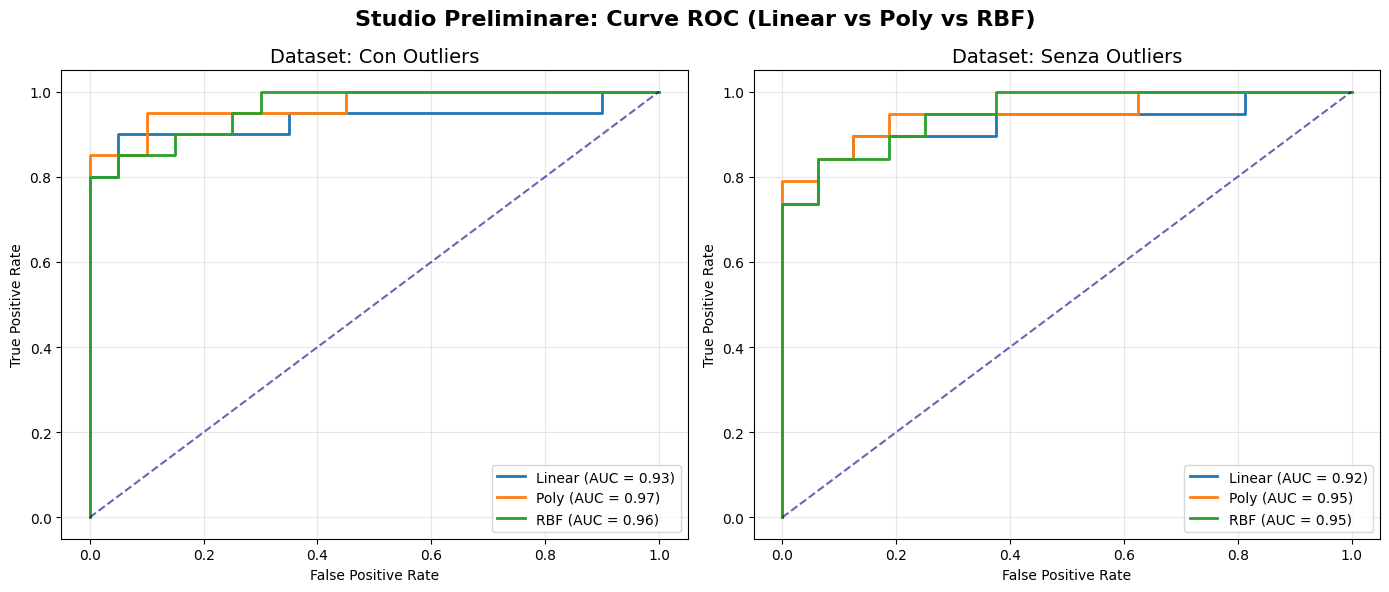

In [16]:
# --- PLOT 1: ROC CURVES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Studio Preliminare: Curve ROC (Linear vs Poly vs RBF)', fontsize=16, fontweight='bold')

for i, ds_name in enumerate(datasets.keys()):
    ax = axes[i]
    for model_name in models_pre.keys():
        res = results_plot[ds_name][model_name]
        ax.plot(res['fpr_roc'], res['tpr_roc'], linewidth=2, label=f"{model_name} (AUC = {res['auc']:.2f})")
    ax.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.6)
    ax.set_title(f'Dataset: {ds_name}', fontsize=14); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

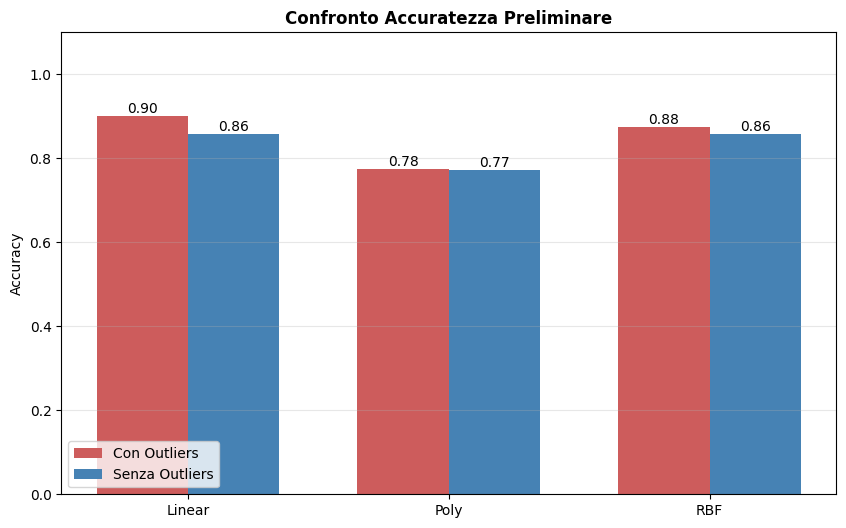

In [17]:
# --- PLOT 2: ACCURATEZZE A BARRE ---
acc_outliers = [results_plot['Con Outliers'][m]['acc'] for m in models_pre.keys()]
acc_no_outliers = [results_plot['Senza Outliers'][m]['acc'] for m in models_pre.keys()]

x = np.arange(len(models_pre)); width = 0.35 
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, acc_outliers, width, label='Con Outliers', color='indianred')
ax.bar(x + width/2, acc_no_outliers, width, label='Senza Outliers', color='steelblue')

ax.set_ylabel('Accuracy'); ax.set_title('Confronto Accuratezza Preliminare', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models_pre.keys())
ax.legend(loc='lower left'); ax.set_ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', alpha=0.3)
plt.show()

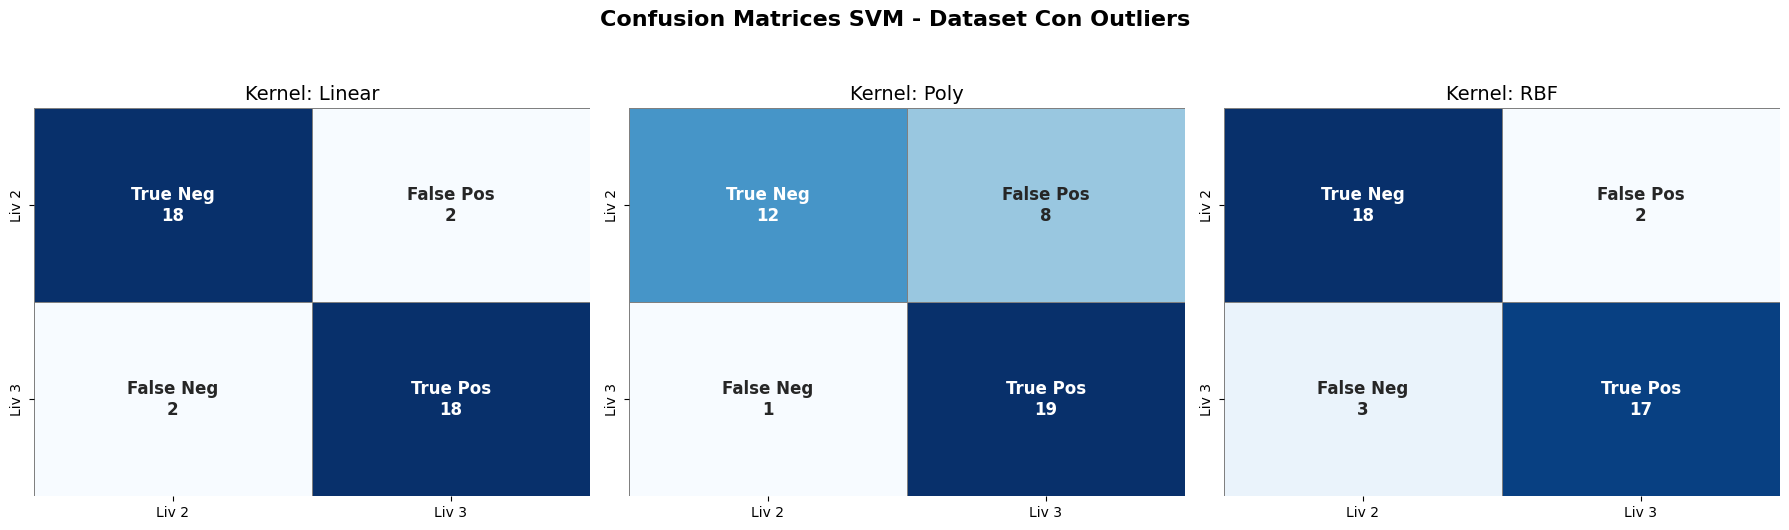

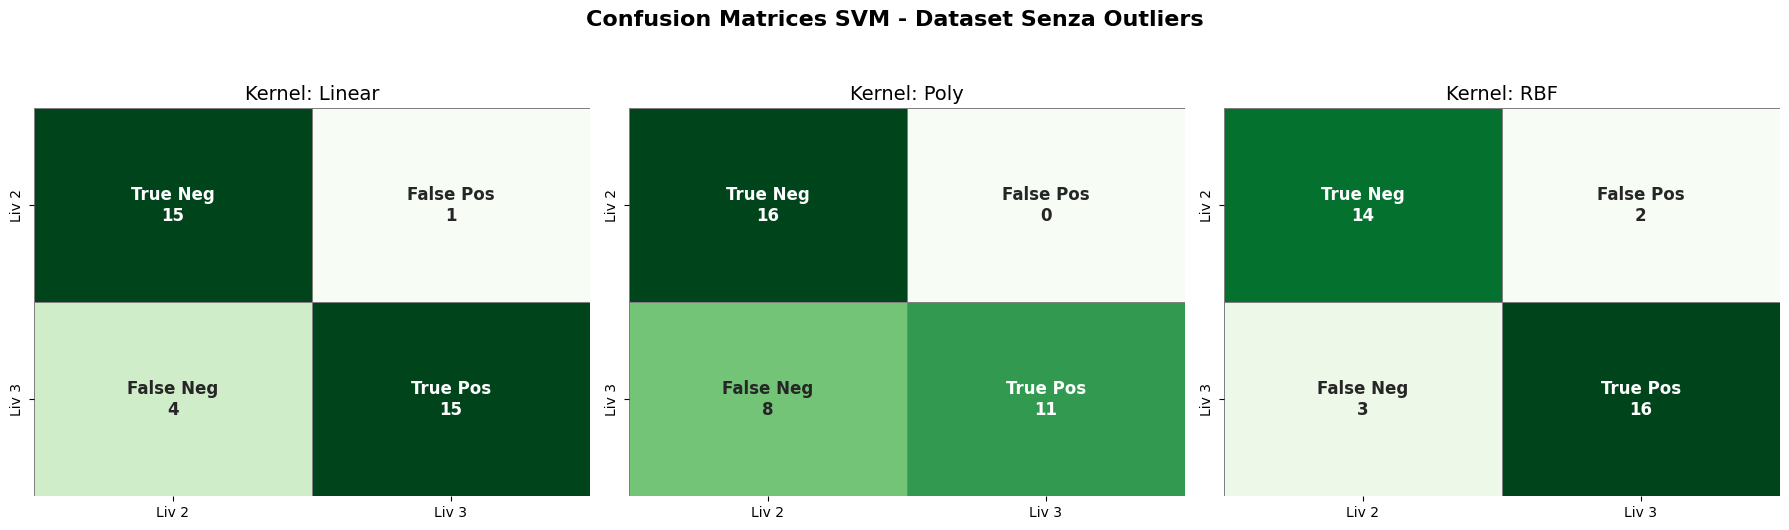

In [18]:
# --- PLOT 3: CONFUSION MATRICES ---
for ds_name, color_map in zip(['Con Outliers', 'Senza Outliers'], ['Blues', 'Greens']):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrices SVM - Dataset {ds_name}', fontsize=16,
                 y=1.05, fontweight='bold')
    for j, model_name in enumerate(models_pre.keys()):
        ax = axes[j]; cm = results_plot[ds_name][model_name]['cm']
        
        labels = np.asarray([f"True Neg\n{cm[0,0]}", f"False Pos\n{cm[0,1]}",
                             f"False Neg\n{cm[1,0]}", f"True Pos\n{cm[1,1]}"]).reshape(2,2)
        
        sns.heatmap(cm, annot=labels, fmt='', cmap=color_map, cbar=False, ax=ax,
                    xticklabels=['Liv 2', 'Liv 3'], yticklabels=['Liv 2', 'Liv 3'],
                    annot_kws={"size": 12, "fontweight": "bold"}, linewidths=0.5, linecolor='grey')
        
        ax.set_title(f"Kernel: {model_name}", fontsize=14)
        
    plt.tight_layout()
    plt.show()

### 3.3 - GridsearchCV dei parametri

Dallo studio preliminare notiamo che il modello con kernel lineare non riesce a separare bene le classi restituendo un'accuratezza molto bassa, a differenza invece dei modelli con kernel Poly o RBF. Di conseguenza, effettuiamo una GridSearchCV per vedere se questo comportamento derivi dai parametri scelti o dal comportamento strutturale di un kernel lineare.

In [19]:
# CROSS VALIDATION: SVM E RANDOM FOREST SU ENTRAMBI I DATASET
cv_folds = [5, 7, 9]

param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.001, 0.1, 1, 5, 10]},
    {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 5, 10], 'degree': [2, 3], 'gamma': ['scale', 0.1]},
    {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 5, 10], 'gamma': ['scale', 0.1, 0.01, 0.001]}
]

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 8],
    'min_samples_split': [2, 5, 10]
}

results = {'Con Outliers': {}, 'Senza Outliers': {}}
best_models = {}

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    print(f"\n{'='*70}")
    print(f" ANALISI DATASET: {ds_name.upper()} ")
    print(f"{'='*70}")
    
    # Salviamo l'intera "Grid" vincente
    best_svm_grid = None; best_rf_grid = None
    best_svm_fold = 0; best_rf_fold = 0
    
    # Testiamo le varie opzioni di Cross-Validation
    for folds in cv_folds:
        cv_strategy = StratifiedKFold(n_splits=folds, shuffle=True, random_state=11)
        
        # --- Ottimizzazione SVM ---
        grid_svm = GridSearchCV(svm.SVC(probability=True, random_state=11), param_grid_svm, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        grid_svm.fit(X_tr, y_tr)
        
        # Salviamo la grid migliore
        if best_svm_grid is None or grid_svm.best_score_ > best_svm_grid.best_score_:
            best_svm_grid = grid_svm
            best_svm_fold = folds
            
        # --- Ottimizzazione Random Forest ---
        grid_rf = GridSearchCV(RandomForestClassifier(random_state=11), param_grid_rf, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        grid_rf.fit(X_tr, y_tr)
        
        # Salviamo la grid migliore
        if best_rf_grid is None or grid_rf.best_score_ > best_rf_grid.best_score_:
            best_rf_grid = grid_rf
            best_rf_fold = folds
            
    # Salviamo i modelli estratti dalle grid vincenti
    best_models[ds_name] = {'SVM': best_svm_grid.best_estimator_, 'RandomForest': best_rf_grid.best_estimator_}
    
    # STAMPA A VIDEO DELLA "TOP 3"
    print(f"\n>>> RISULTATI CROSS-VALIDATION SVM (Miglior fold: {best_svm_fold}) <<<")
    means = best_svm_grid.cv_results_['mean_test_score']
    stds = best_svm_grid.cv_results_['std_test_score']
    params = best_svm_grid.cv_results_['params']
    
    # Ordiniamo gli indici dal risultato migliore al peggiore e prendiamo i primi 3
    sorted_idx = means.argsort()[::-1][:3]
    for rank, i in enumerate(sorted_idx, 1):
        print(f" {rank}° Posto | AUC Media: {means[i]:.4f} (±{stds[i]:.4f}) | Parametri: {params[i]}")

    print(f"\n>>> RISULTATI CROSS-VALIDATION RANDOM FOREST (Miglior fold: {best_rf_fold}) <<<")
    means_rf = best_rf_grid.cv_results_['mean_test_score']
    stds_rf = best_rf_grid.cv_results_['std_test_score']
    params_rf = best_rf_grid.cv_results_['params']
    
    sorted_idx_rf = means_rf.argsort()[::-1][:3]
    for rank, i in enumerate(sorted_idx_rf, 1):
        print(f" {rank}° Posto | AUC Media: {means_rf[i]:.4f} (±{stds_rf[i]:.4f}) | Parametri: {params_rf[i]}")

    # VALUTAZIONE FINALE SUL TEST SET
    print("\n>>> PERFORMANCE SUL TEST SET <<<")
    for model_name, model in best_models[ds_name].items():
        y_pred = model.predict(X_te)
        y_score = model.decision_function(X_te) if hasattr(model, "decision_function") else model.predict_proba(X_te)[:, 1]
            
        acc = accuracy_score(y_te, y_pred)
        fpr_roc, tpr_roc, _ = roc_curve(y_te, y_score, pos_label=3)
        roc_auc = auc(fpr_roc, tpr_roc)
        
        results[ds_name][model_name] = {
            'acc': acc, 'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc,
            'report': classification_report(y_te, y_pred)
        }
        print(f" - {model_name:<15}: Accuratezza = {acc:.4f} | AUC = {roc_auc:.4f}")


 ANALISI DATASET: CON OUTLIERS 

>>> RISULTATI CROSS-VALIDATION SVM (Miglior fold: 9) <<<
 1° Posto | AUC Media: 0.9607 (±0.0338) | Parametri: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
 2° Posto | AUC Media: 0.9564 (±0.0360) | Parametri: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
 3° Posto | AUC Media: 0.9472 (±0.0584) | Parametri: {'C': 0.001, 'kernel': 'linear'}

>>> RISULTATI CROSS-VALIDATION RANDOM FOREST (Miglior fold: 9) <<<
 1° Posto | AUC Media: 0.9475 (±0.0452) | Parametri: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
 2° Posto | AUC Media: 0.9456 (±0.0308) | Parametri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
 3° Posto | AUC Media: 0.9443 (±0.0314) | Parametri: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 300}

>>> PERFORMANCE SUL TEST SET <<<
 - SVM            : Accuratezza = 0.8750 | AUC = 0.9625
 - RandomForest   : Accuratezza = 0.9000 | AUC = 0.9575

 ANALISI DATASET: SENZA OUTLIERS 

>>> RISULTATI CROSS-VALIDATION

In [20]:
# STAMPA DEL REPORT FINALE PER IL DATASET SENZA OUTLIERS
print("\n" + "="*50)
print(" REPORT CLASSIFICAZIONE FINALE (Senza Outliers) ")
print("="*50)
print("\n--- Support Vector Machine ---")
print(results['Senza Outliers']['SVM']['report'])
print("\n--- Random Forest ---")
print(results['Senza Outliers']['RandomForest']['report'])


 REPORT CLASSIFICAZIONE FINALE (Senza Outliers) 

--- Support Vector Machine ---
              precision    recall  f1-score   support

           2       0.82      0.88      0.85        16
           3       0.89      0.84      0.86        19

    accuracy                           0.86        35
   macro avg       0.86      0.86      0.86        35
weighted avg       0.86      0.86      0.86        35


--- Random Forest ---
              precision    recall  f1-score   support

           2       0.88      0.88      0.88        16
           3       0.89      0.89      0.89        19

    accuracy                           0.89        35
   macro avg       0.88      0.88      0.88        35
weighted avg       0.89      0.89      0.89        35



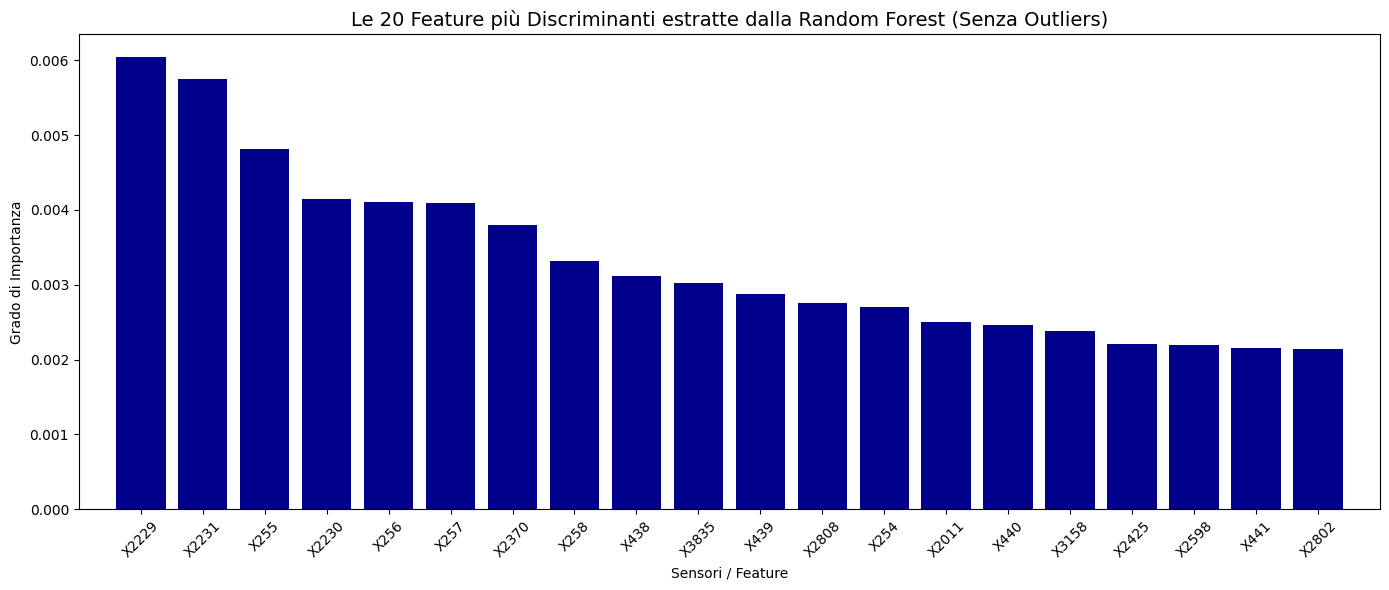

In [21]:
# FEATURE IMPORTANCE RANDOM FOREST (Miglior Modello senza Outliers)
best_rf_no_out = best_models['Senza Outliers']['RandomForest']
importances = best_rf_no_out.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 20
plt.figure(figsize=(14, 6))
plt.title("Le 20 Feature più Discriminanti estratte dalla Random Forest (Senza Outliers)", fontsize=14)
plt.bar(range(top_k), importances[indices][:top_k], align="center", color='darkblue')
plt.xticks(range(top_k), [X_train_no.columns[i] for i in indices[:top_k]], rotation=45)
plt.ylabel("Grado di Importanza")
plt.xlabel("Sensori / Feature")
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()


Random Forest Accuracy: 0.8857


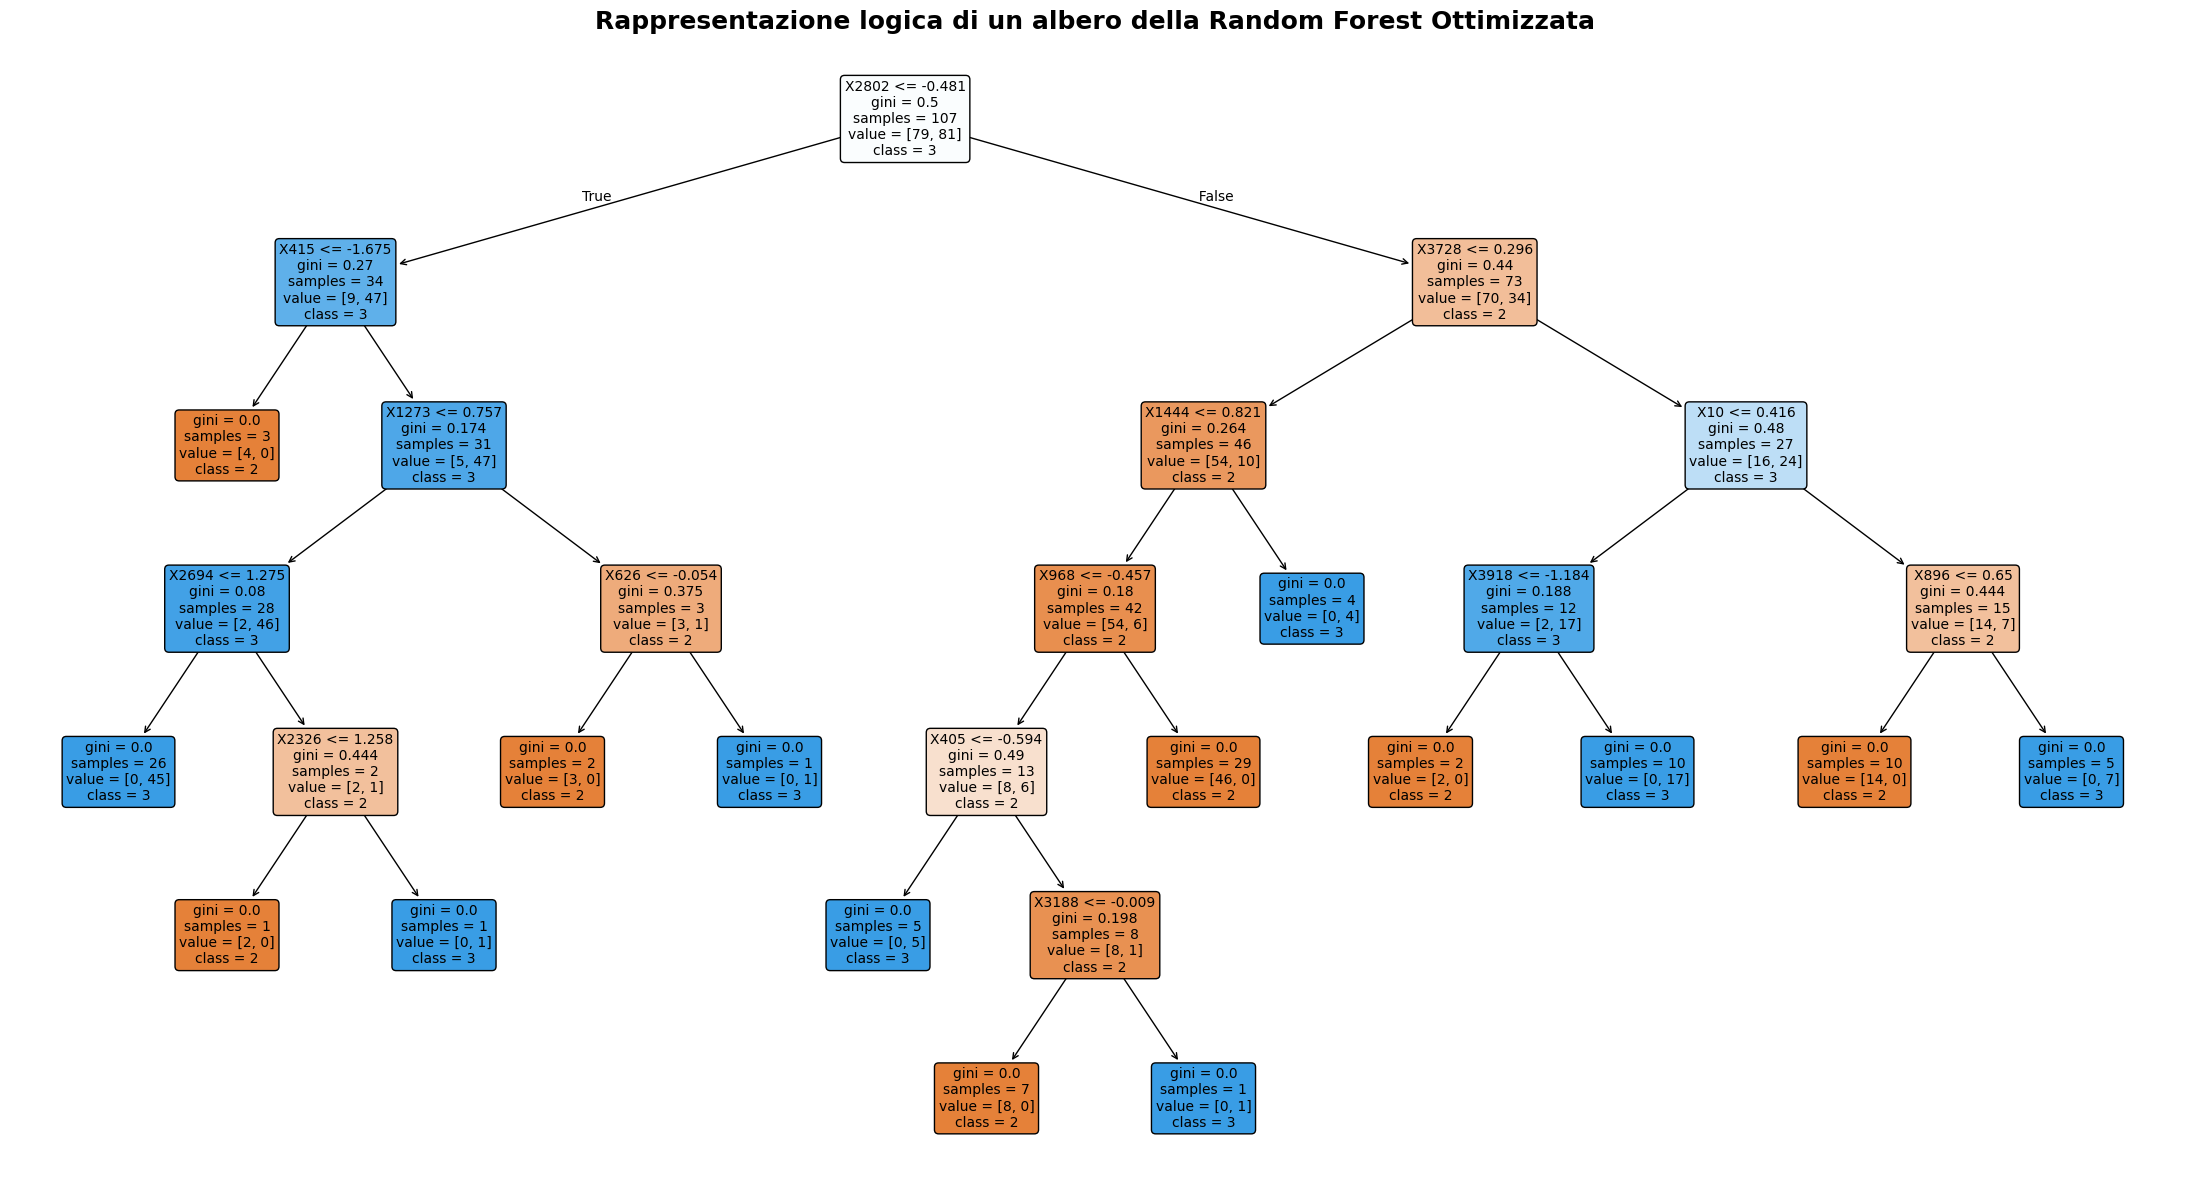

In [22]:
# RAPPRESENTAZIONE GRAFICA DELL'ALBERO RANDOM FOREST (Senza Outliers)
from sklearn.tree import plot_tree

# Estraiamo automaticamente il modello VINCITORE calcolato dal blocco GridSearchCV
miglior_rf = best_models['Senza Outliers']['RandomForest']

# Calcoliamo l'accuratezza specifica di questo modello sul Test Set
y_pred_rf = miglior_rf.predict(X_test_no)
acc_rf = accuracy_score(y_test_no, y_pred_rf)
print(f"\nRandom Forest Accuracy: {acc_rf:.4f}")

plt.figure(figsize=(22, 12))
class_names = [str(c) for c in miglior_rf.classes_]

# Stampiamo il primo albero della foresta (indice 0)
plot_tree(
    miglior_rf.estimators_[0],
    feature_names=X_train_no.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=None,
    fontsize=10
)

plt.title("Rappresentazione logica di un albero della Random Forest Ottimizzata",
          fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 - Voting sulla svm.SVC

In [23]:
# VOTING CON SVM (ENSEMBLE DEI FOLD)
from scipy.stats import mode
from sklearn.model_selection import cross_validate

print("\n" + "="*50)
print(" RISULTATI DEL VOTING SVM ")
print("="*50)

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    # Prendiamo la miglior SVM trovata per questo dataset
    miglior_svm = best_models[ds_name]['SVM']
    
    # Usiamo 9 fold per estrarre 9 modelli diversi
    cv_voting = StratifiedKFold(n_splits=9, shuffle=True, random_state=11)
    cv_results = cross_validate(miglior_svm, X_tr, y_tr, cv=cv_voting, return_estimator=True)
    
    # Salviamo i 9 modelli addestrati
    modelli_addestrati = cv_results['estimator']
    
    # Facciamo predire il Test Set a ogni singolo modello (9 predizioni per ogni riga)
    predizioni_folds = np.array([mod.predict(X_te) for mod in modelli_addestrati])
    
    # VOTING: Applichiamo la moda per prendere la classe più votata dai modelli
    pred_voting, _ = mode(predizioni_folds, axis=0)
    pred_voting = pred_voting.flatten()
    
    print(f"\n--- Voting SVM: Dataset {ds_name} ---")
    print(f"Accuracy del voting: {accuracy_score(y_te, pred_voting):.4f}")
    print(classification_report(y_te, pred_voting))


 RISULTATI DEL VOTING SVM 

--- Voting SVM: Dataset Con Outliers ---
Accuracy del voting: 0.8750
              precision    recall  f1-score   support

           2       0.86      0.90      0.88        20
           3       0.89      0.85      0.87        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40


--- Voting SVM: Dataset Senza Outliers ---
Accuracy del voting: 0.8571
              precision    recall  f1-score   support

           2       0.82      0.88      0.85        16
           3       0.89      0.84      0.86        19

    accuracy                           0.86        35
   macro avg       0.86      0.86      0.86        35
weighted avg       0.86      0.86      0.86        35



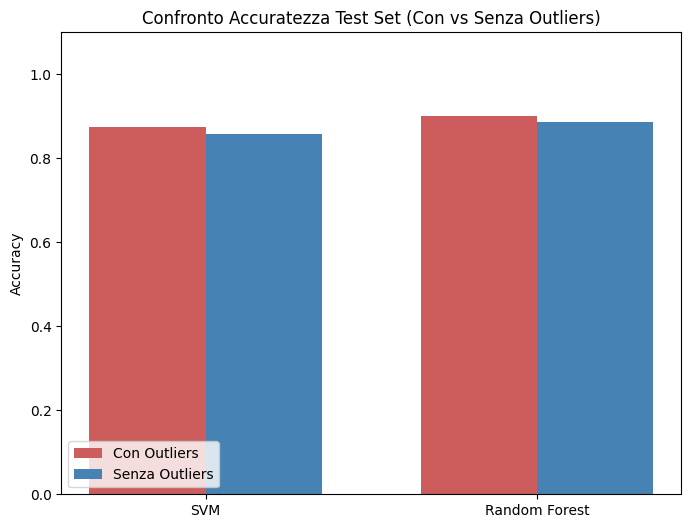

In [24]:
# PLOT GRAFICI COMPARATIVI (Accuratezza e ROC)
acc_out = [results['Con Outliers'][m]['acc'] for m in ['SVM', 'RandomForest']]
acc_no_out = [results['Senza Outliers'][m]['acc'] for m in ['SVM', 'RandomForest']]

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35; x = np.arange(2)
ax.bar(x - width/2, acc_out, width, label='Con Outliers', color='indianred')
ax.bar(x + width/2, acc_no_out, width, label='Senza Outliers', color='steelblue')
ax.set_ylabel('Accuracy'); ax.set_title('Confronto Accuratezza Test Set (Con vs Senza Outliers)')
ax.set_xticks(x); ax.set_xticklabels(['SVM', 'Random Forest'])
ax.legend(loc='lower left')
ax.set_ylim(0, 1.1)
plt.show()

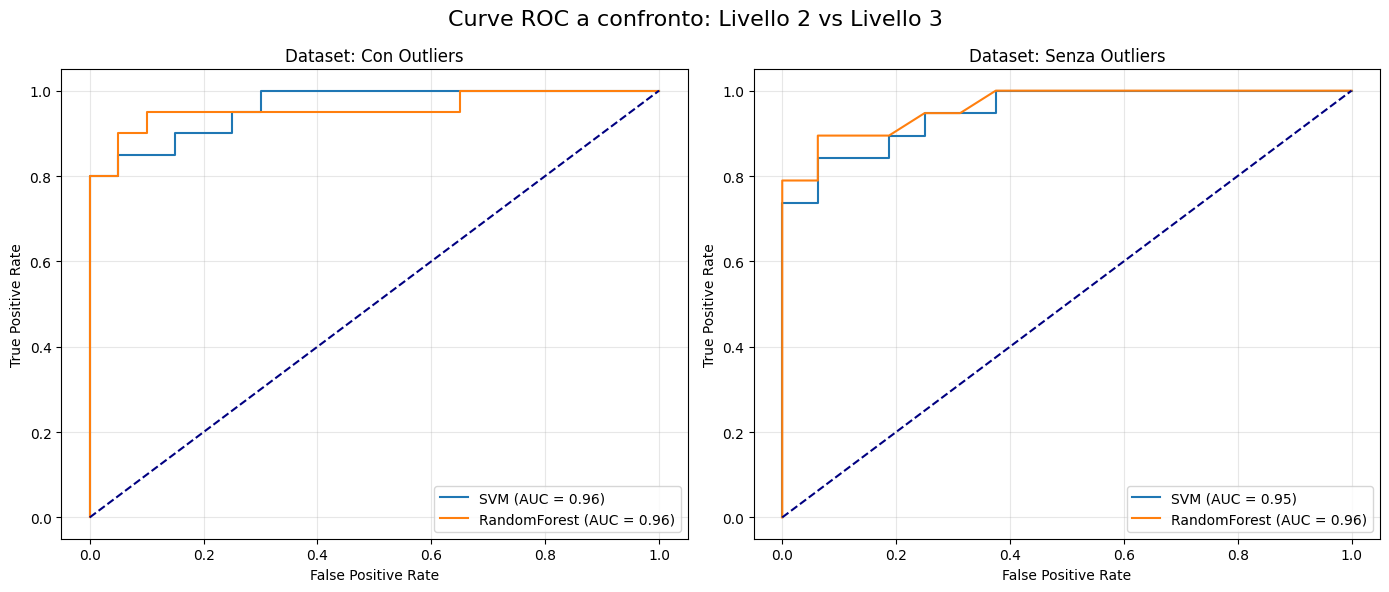

In [25]:
# Curve ROC 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curve ROC a confronto: Livello 2 vs Livello 3', fontsize=16)

for i, ds_name in enumerate(datasets.keys()):
    ax = axes[i]
    for model_name in ['SVM', 'RandomForest']:
        res = results[ds_name][model_name]
        ax.plot(res['fpr_roc'], res['tpr_roc'], label=f"{model_name} (AUC = {res['auc']:.2f})")
    
    ax.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax.set_title(f'Dataset: {ds_name}')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

E' POSSIBILE USARE SOLO PARTE DEL SEGNALE E QUINDI FERMARSI A UN MINOR TEMPO DI REGISTRAZIONE? MIGLIORA O PEGGIORA?

In [26]:
# Analisi su Finestra Temporale Ridotta (0.5 secondi)
print("\n" + "="*70)
print(" TEST: CLASSIFICAZIONE SU MEZZO SECONDO DI REGISTRAZIONE (0.5s) ")
print("="*70)

# 1 secondo di registrazione = 4096 campioni.
# Mezzo secondo (0.5s) = 2048 campioni.
# Tagliamo i dataset (Senza Outliers) prendendo solo la prima metà del segnale temporale
X_train_half = X_train_no.iloc[:, :2048]
X_test_half = X_test_no.iloc[:, :2048]

# Prendiamo i parametri del miglior modello SVM trovato in precedenza
migliori_parametri_svm = best_models['Senza Outliers']['SVM'].get_params()
svm_half = svm.SVC(**migliori_parametri_svm)


# Addestriamo e testiamo sul segnale "dimezzato"
svm_half.fit(X_train_half, y_train_no)
y_pred_half = svm_half.predict(X_test_half)
y_score_half = svm_half.decision_function(X_test_half)

acc_half = accuracy_score(y_test_no, y_pred_half)
fpr_half, tpr_half, _ = roc_curve(y_test_no, y_score_half, pos_label=3)
auc_half = auc(fpr_half, tpr_half)

print(f"Modello SVM ottimizzato addestrato SOLO sulle prime 2048 feature (0.5 secondi):")
print(f" - Accuratezza Test Set : {acc_half:.4f} (rispetto all'analisi completa di 1s)")
print(f" - AUC Test Set         : {auc_half:.4f}\n")



 TEST: CLASSIFICAZIONE SU MEZZO SECONDO DI REGISTRAZIONE (0.5s) 
Modello SVM ottimizzato addestrato SOLO sulle prime 2048 feature (0.5 secondi):
 - Accuratezza Test Set : 0.8000 (rispetto all'analisi completa di 1s)
 - AUC Test Set         : 0.9309



## 4 - Conclusioni
L'analisi del dataset riguardande i segnali EEG per riconoscere lapresenza di epilessia nei pazienti ha fatto emergere un dualismo tra i modelli utilizzati. La SVM ha mostrato performance leggermente superiori sul dataset originale (con outliers), mentre la Random Forest ha ottenuto un miglioramento maggiormente della pulizia del dato. Questo si spiega con la natura clinica del segnale EEG: statisticamente, un picco estremo è un outlier, ma clinicamente rappresenta il pattern epilettico. La SVM riesce a sfruttare questi picchi estremi come Support Vectors per tracciare i margini decisionali riguardanti la scelta degli outliers, mentre la Random Forest ne viene 'distratta' andando in overfitting. La pulizia del dato ha quindi rimosso il rumore, costringendo la Random Forest a imparare regole più generalizzabili sulla morfologia dell'onda, aumentandone l'accuratezza sul Test Set.

In [27]:
df2_RF = pd.DataFrame(columns=df2.columns) # Real Fourier Transform
df2_IF = pd.DataFrame(columns=df2.columns) # Imag Fourier Transform
df2_Fourier = pd.DataFrame(columns=df2.columns)

for i in range(df2.shape[0]):
    row = np.fft.fft(scale2.iloc[i])
    df2_RF.loc[i] = np.real(row)
    df2_IF.loc[i] = np.imag(row)
    df2_Fourier.loc[i] = np.abs(row)
df2_Fourier.shape

df3_RF = pd.DataFrame(columns=df3.columns) # Real Fourier Transform
df3_IF = pd.DataFrame(columns=df3.columns) # Imag Fourier Transform
df3_Fourier = pd.DataFrame(columns=df3.columns)

for i in range(df2.shape[0]):
    row = np.fft.fft(scale3.iloc[i])
    df3_RF.loc[i] = np.real(row)
    df3_IF.loc[i] = np.imag(row)
    df3_Fourier.loc[i] = np.abs(row)

#df3_Fourier.drop(columns = 0)


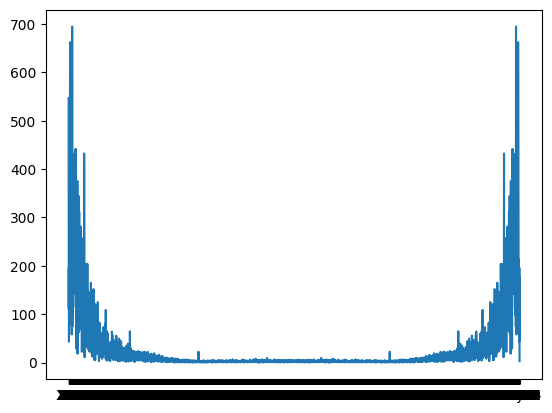

In [33]:
plt.plot(df3_Fourier.iloc[1])

Text(0.5, 1.0, 'Misurazioni livello 2')

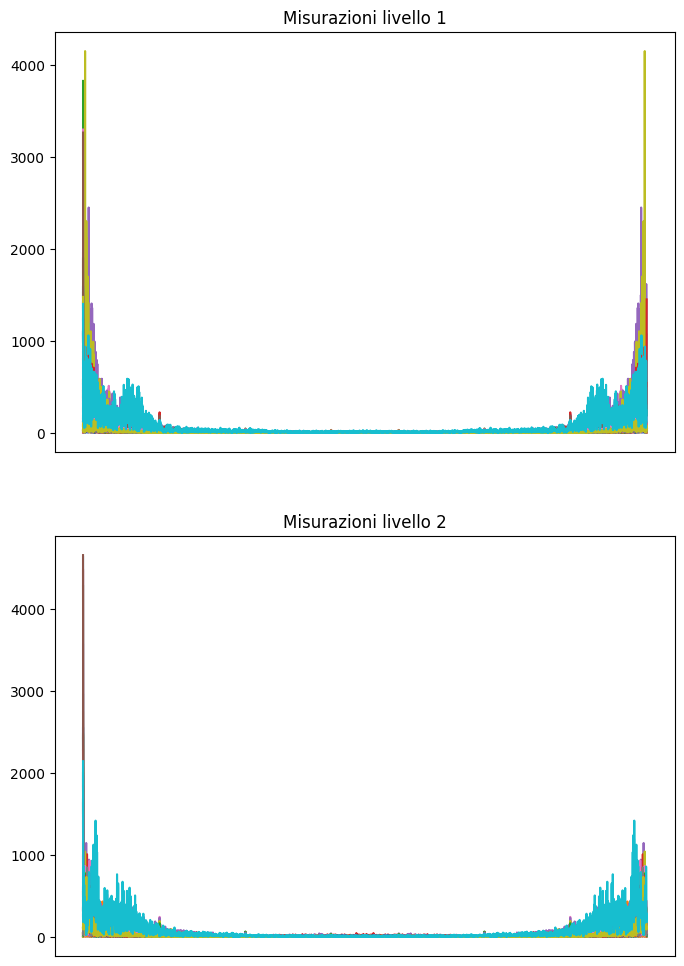

In [29]:
fig = plt.figure(figsize=(8,12))
plt.subplot(211)
plt.plot(df2_Fourier.T)
plt.xticks([])
plt.title("Misurazioni livello 1")
#plt.ylim(-5, 5) # Set y-axis

plt.subplot(212)
plt.plot(df3_Fourier.T)
plt.xticks([])
plt.title("Misurazioni livello 2")
#plt.ylim(-5, 5) # Set y-axis

In [30]:
#   Creo il Train Test split per Fourier. All'interno avrò:
#           - aggiungo la colonna y con la label giusta
#           - splitto in train e test
#           - divido in X e Y per train e test

df2_Fourier['y'] = 2
df3_Fourier['y'] = 3

train_FFT= pd.concat([df2_Fourier.iloc[:80], df3_Fourier.iloc[:80]])
test_FFT= pd.concat([df2_Fourier.iloc[80:], df3_Fourier.iloc[80:]])

X_train_FFT = train_FFT.drop(columns=['y'])
y_train_FFT = train_FFT['y']
X_test_FFT = test_FFT.drop(columns=['y'])
y_test_FFT = test_FFT['y']

In [31]:
# STUDIO PRELIMINARE: Confronto Kernel SVM (Linear, Poly, RBF)
results_plot = {'Con Outliers': {}, 'Senza Outliers': {}}

# for ds_name, (X_train, y_train, X_test, y_test) in datasets.items():
#     # Inizializziamo modelli standard per un'analisi "baseline"
models_pre = {
    'Linear': svm.SVC(kernel='linear', C=0.001, random_state=11),
    'Poly': svm.SVC(kernel='poly', degree=3, C=5, gamma='scale', random_state=11),
    'RBF': svm.SVC(kernel='rbf', C=5, gamma='scale', random_state=11)
}

for model_name, clf in models_pre.items():
    clf.fit(X_train_FFT, y_train_FFT)
    y_pred_FFT = clf.predict(X_test_FFT)
    y_score_FFT = clf.decision_function(X_test_FFT)
    
    acc = accuracy_score(y_test_FFT, y_pred_FFT)
    cm = confusion_matrix(y_test_FFT, y_pred_FFT, labels=[2, 3])
    
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    fpr_roc, tpr_roc, _ = roc_curve(y_test_FFT, y_score_FFT, pos_label=3)
    roc_auc = auc(fpr_roc, tpr_roc)
    
    results_plot[ds_name][model_name] = {
        'acc': acc, 'cm': cm, 'tpr': tpr, 'tnr': tnr, 
        'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc
    }
acc

0.775